# Diagnostic peak mining 

This notebook can be used to mine for the diagnotic peak series of a PTM; in raw MS data or in search output data from MaxQuant. 

In [14]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter
from pyopenms import * # We use pyopenms to read the raw data as mzml. Convert from raw to mzml with your chosen file converter
from collections import Counter

plt.rcParams["font.family"] = "Arial"

Determination of memory status is not supported on this 
 platform, measuring for memoryleaks will never fail


In [15]:
msms = "PATH_TO/txt/msms.txt" 
mzml = "PATH_TO/FILE.mzML"

## Theoretical d-ions 

In [17]:
def calculate_monomass(aa):
    '''
    Calulate the monoisotopic mass of amino acids.
    Input: String, single letter amino acid abbreviation
    Return: float 
    '''
    
    atom_masses = {
        "H": 1.007825,
        "C": 12.000000,
        "N": 14.003074,
        "O": 15.994915,
        "S": 31.972071
    }

    aa_composition = {
        "A": {"C": 3, "H": 5, "N": 1, "O": 1},
        "R": {"C": 6, "H": 12, "N": 4, "O": 1},
        "N": {"C": 4, "H": 6, "N": 2, "O": 2},
        "D": {"C": 4, "H": 5, "N": 1, "O": 3},
        "C": {"C": 3, "H": 5, "N": 1, "O": 1, "S": 1},
        "E": {"C": 5, "H": 7, "N": 1, "O": 3},
        "Q": {"C": 5, "H": 8, "N": 2, "O": 2},
        "G": {"C": 2, "H": 3, "N": 1, "O": 1},
        "H": {"C": 6, "H": 7, "N": 3, "O": 1},
        "I": {"C": 6, "H": 11, "N": 1, "O": 1},
        "L": {"C": 6, "H": 11, "N": 1, "O": 1},
        "K": {"C": 6, "H": 12, "N": 2, "O": 1},
        "M": {"C": 5, "H": 9, "N": 1, "O": 1, "S": 1},
        "F": {"C": 9, "H": 9, "N": 1, "O": 1},
        "P": {"C": 5, "H": 7, "N": 1, "O": 1},
        "S": {"C": 3, "H": 5, "N": 1, "O": 2},
        "T": {"C": 4, "H": 7, "N": 1, "O": 2},
        "W": {"C": 11, "H": 10, "N": 2, "O": 1},
        "Y": {"C": 9, "H": 9, "N": 1, "O": 2},
        "V": {"C": 5, "H": 9, "N": 1, "O": 1}
    }

    monomass = 0
    if aa in aa_composition:
        composition = aa_composition[aa]
        for atom, count in composition.items():
            monomass += count * atom_masses[atom]
    else:
        raise ValueError(f"Invalid amino acid: {aa}")

    return monomass

In [18]:
def find_mass_diff(remn_seq, ion="b-ion"):

    diff_list = [0]
    aa_mass_list = [0]
    temp = 0

    # reverses the order
    if ion != "b-ion":
        remn_seq = "".join(reversed(list(remn_seq)))

    for aa in list(remn_seq):
        temp += calculate_monomass(aa) 

        if ion == "b-ion":
            # one proton is added in the mass spec for diagnostic peaks + 1.007825
            diff_list.append(temp) #  + 1.007825 
        if ion == "y-ion": # y-ion
            diff_list.append(temp)

        aa_mass_list.append(calculate_monomass(aa))

    return diff_list, aa_mass_list

In [19]:
def diagnostic_peaks(sequence): 
    """A script that takeds a sequence of a modification and 
    returns all possible diagnostic peaks."""
    
    list_all_comb = list({sequence[a:a+k] for k in range(1,1+len(sequence)) 
             for a in range(1+len(sequence)-k)})
    
    list_with_things = []
    
    for k in range(1,1+len(sequence)):
         for a in range(1+len(sequence)-k):
            list_item = sequence[a:a+k]
            list_with_things.append(list_item)
            
    sorted_diag = sorted(list_all_comb, key=len)
    
    # calculate the masses of the peaks 
    masses_dict = {}
    for m in range(len(sorted_diag)): 
        split_sequence = list(sorted_diag[m])
        diag_mass = 0
        for amino_acid in split_sequence:
            diag_mass = diag_mass + calculate_monomass(amino_acid)
            masses_dict[sorted_diag[m]] = diag_mass 
    
    return masses_dict

In [20]:
sumo_diagnostic_peaks = diagnostic_peaks("DVFQQQTGG")
sumo_diagnostic_peaks

{'Q': 128.058578,
 'D': 115.026944,
 'V': 99.068414,
 'G': 57.021464,
 'F': 147.068414,
 'T': 101.047679,
 'QT': 229.10625700000003,
 'GG': 114.042928,
 'TG': 158.069143,
 'QQ': 256.117156,
 'VF': 246.13682799999998,
 'DV': 214.095358,
 'FQ': 275.126992,
 'QQQ': 384.17573400000003,
 'QTG': 286.127721,
 'FQQ': 403.18557,
 'DVF': 361.163772,
 'QQT': 357.16483500000004,
 'VFQ': 374.195406,
 'TGG': 215.090607,
 'VFQQ': 502.253984,
 'QQQT': 485.22341300000005,
 'QQTG': 414.186299,
 'FQQQ': 531.244148,
 'DVFQ': 489.22235,
 'QTGG': 343.149185,
 'VFQQQ': 630.3125620000001,
 'QQQTG': 542.2448770000001,
 'DVFQQ': 617.280928,
 'FQQQT': 632.291827,
 'QQTGG': 471.207763,
 'DVFQQQ': 745.339506,
 'QQQTGG': 599.2663410000001,
 'VFQQQT': 731.3602410000001,
 'FQQQTG': 689.313291,
 'DVFQQQT': 846.387185,
 'FQQQTGG': 746.3347550000001,
 'VFQQQTG': 788.3817050000001,
 'DVFQQQTG': 903.4086490000001,
 'VFQQQTGG': 845.4031690000002,
 'DVFQQQTGG': 960.4301130000001}

In [21]:
# Find theoretical SUMO peaks for labelling the plots 
sumo23 = "DVFQQQTGG"
sumo_ds = find_mass_diff(sumo23)[0][1:10] # difflist is first object  

# We know the most common ones and add them to the list
mass_dict = {
    'QQ': 256.11716,  'FQ': 275.12699,  
     'FQQ': 403.18557, 'DVF': 361.16376, 
    'TGG': 215.0906, 'DVFQ': 489.22234000000003, 'DVFQQ': 617.28092, 'DVFQQQ': 745.3395, 
    'DVFQQQT': 846.3871800000001, 'DVFQQQTGG': 960.4301000000002
}

sumo_ds.append(403.18557)
#sumo_ds.append(215.0906) 'TGG', 
sumo_ds.append(275.12699) 
sumo_ds.append(256.11716) 

# list of labels 
tick_labels = ['d1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'FQQ', 'FQ', 'QQ']

# Final list of masses to label
sumo_ds

[115.026944,
 214.095358,
 361.163772,
 489.22235,
 617.280928,
 745.339506,
 846.387185,
 903.4086490000001,
 960.4301130000001,
 403.18557,
 275.12699,
 256.11716]

## Based on the mzml file

In [22]:
e = MSExperiment()
MzMLFile().load(sumo_mzml, e)  
print(e.getNrSpectra())

31317


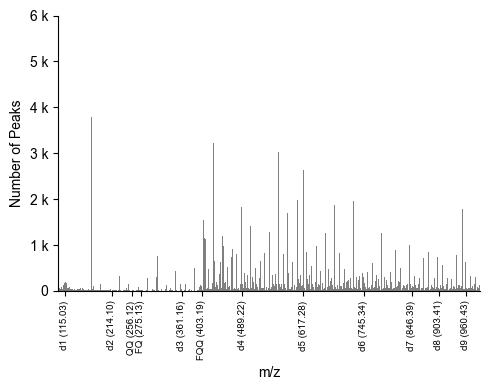

In [23]:
mz_values = []
for s in e:
    for mz, i in zip(*s.get_peaks()):
        mz_values.append(mz)

myRoundedList = np.round(mz_values, 4)

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(myRoundedList, bins=500000, color='grey', edgecolor=None)

ax.set_xticks(sumo_ds)
ax.set_xticklabels([f'{label} ({mass:.2f})' for label, mass in zip(tick_labels, sumo_ds)], rotation=90)
ax.set_title("")
ax.set_xlabel("m/z")
ax.set_xlim(100, 990)
ax.set_ylim(0, 6000)
ax.set_ylabel("Number of Peaks")
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(fontsize=7)
fig.tight_layout()
plt.show()

## Based on the MaxQuant output table msms.txt  

Runs much faster than reading the raw data directly. 

In [24]:
def import_and_filter_msms_file(file, sumo = True): 

    df = pd.read_csv(file, sep="\t",low_memory=False) 

    df = df.drop_duplicates(['Raw file', 'Scan number'], keep=False)
    df = df[~df['Matches'].isna()] 

    df["Masses_list"] = [t.split(";") for t in df["Masses"]] 
    df["Matches_list"] = [t.split(";") for t in df["Matches"]] 
    
    return df

def flatten_extend(matrix):
    flat_list = []
    for row in matrix:
        flat_list.extend(row)
    return flat_list

In [25]:
msms = import_and_filter_msms_file(msms) # change file 

long_list = flatten_extend(msms["Masses_list"])
myRoundedList = [round(float(current_integer), 2) for current_integer in long_list]
vc = pd.Series(myRoundedList).value_counts()
df = vc.to_frame().reset_index().rename(columns={"index": "mass", 0: "count"}).sort_values(by=["mass"])
df = df.loc[df["count"] > 100000]

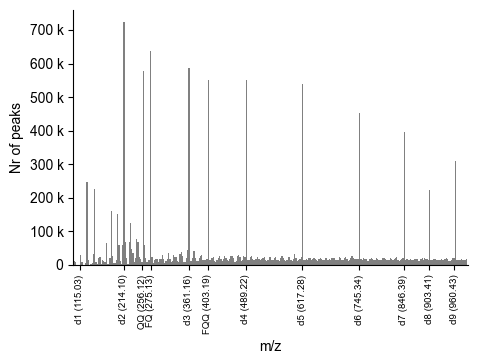

In [27]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(myRoundedList, color='grey', bins=2000)
ax.set_title("") 
ax.set_xlabel("m/z")
ax.set_ylabel("Nr of peaks")

ax.set_xticks(sumo_ds)
ax.set_xticklabels([f'{label} ({mass:.2f})' for label, mass in zip(tick_labels, sumo_ds)], rotation=90)
ax.set_xlim(100, 990)
fig.set_alpha(0)
fig.tight_layout()
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(fontsize=7)
plt.show()

 # Ubiquitin

In [28]:
ubi = "ESTLHLVLRLRGG"
ubi_ds = find_mass_diff(ubi)[0][1:] # difflist is first object  

tick_labels_ubi = ['d1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10', 'd11', 'd12', 'd13']

In [29]:
ubi_ds

[129.042594,
 216.074623,
 317.122302,
 430.206366,
 567.265278,
 680.349342,
 779.4177559999999,
 892.50182,
 1048.602931,
 1161.6869949999998,
 1317.7881059999997,
 1374.8095699999997,
 1431.8310339999996]

In [30]:
msms_ubi = import_and_filter_msms_file(msms_ubi) # change file name

long_list_ubi = flatten_extend(msms_ubi["Masses_list"])
myRoundedList_ubi = [round(float(current_integer), 2) for current_integer in long_list_ubi]
vc_ubi = pd.Series(myRoundedList_ubi).value_counts()
df_ubi = vc_ubi.to_frame().reset_index().rename(columns={"index": "mass", 0: "count"}).sort_values(by=["mass"])
df_ubi = df_ubi.loc[df_ubi["count"] > 100000]

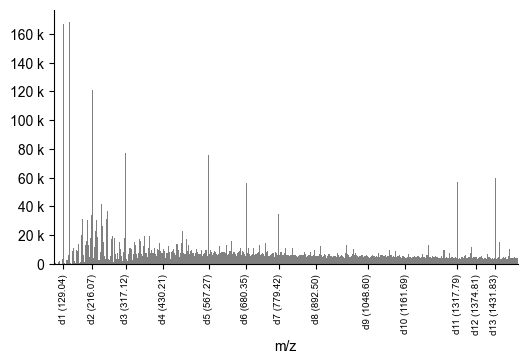

In [31]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.hist(myRoundedList_ubi, color='grey', bins=2000)
ax.set_title("") 
ax.set_xlabel("m/z")
ax.set_ylabel("")

ax.set_xticks(ubi_ds)
ax.set_xticklabels([f'{label} ({mass:.2f})' for label, mass in zip(tick_labels_ubi, ubi_ds)], rotation=90)
ax.set_xlim(100, 1500)
fig.set_alpha(0)
fig.tight_layout()
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(fontsize=7)
plt.show()